# Amazon Stock Price Forecasting using LSTM

## Objective
Predict Amazon stock closing prices using Long Short-Term Memory (LSTM) neural networks.

## Technologies Used
- Python
- Pandas
- NumPy
- TensorFlow/Keras
- Matplotlib
- Scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

In [3]:
df = pd.read_csv('/content/AMZN.csv')

df.head()

,Date,Open,High,Low,Adj Close,Volume,ma7,ma21,26ema,12ema,MACD,20sd,upper_band,lower_band,ema,momentum,Fourier,ARIMA,Close,labels
0,1/4/2010,136.250000,136.610001,133.139999,133.899994,7599900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,133.899994,NaN
1,1/5/2010,133.429993,135.479996,131.809998,134.690002,8851900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,134.690002,NaN
2,1/6/2010,134.600006,134.729996,131.649994,132.250000,7178800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,132.250000,NaN
3,1/7/2010,132.009995,132.320007,128.800003,130.000000,11030200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,130.000000,NaN
4,1/8/2010,130.559998,133.679993,129.029999,133.520004,9830500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,133.520004,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2265 entries, 0 to 2264
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        2265 non-null   object 
 1   Open        2265 non-null   float64
 2   High        2265 non-null   float64
 3   Low         2265 non-null   float64
 4   Adj Close   2265 non-null   float64
 5   Volume      2265 non-null   int64  
 6   ma7         0 non-null      float64
 7   ma21        0 non-null      float64
 8   26ema       0 non-null      float64
 9   12ema       0 non-null      float64
 10  MACD        0 non-null      float64
 11  20sd        0 non-null      float64
 12  upper_band  0 non-null      float64
 13  lower_band  0 non-null      float64
 14  ema         0 non-null      float64
 15  momentum    0 non-null      float64
 16  Fourier     0 non-null      float64
 17  ARIMA       0 non-null      float64
 18  Close       2265 non-null   float64
 19  labels      0 non-null     

In [5]:
df.describe()

,Open,High,Low,Adj Close,Volume,ma7,ma21,26ema,12ema,MACD,20sd,upper_band,lower_band,ema,momentum,Fourier,ARIMA,Close,labels
count,2265.000000,2265.000000,2265.000000,2265.000000,2.265000e+03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2265.000000,0.0
mean,553.000949,558.568702,546.430821,552.743179,4.603646e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,552.743179,NaN
std,470.155920,474.660681,463.993737,469.357785,2.954860e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,469.357785,NaN
min,105.930000,111.290001,105.800003,108.610001,9.844000e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,108.610001,NaN
25%,217.649994,219.979996,214.460007,217.830002,2.786500e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,217.830002,NaN
50%,334.679993,336.760010,328.940002,332.910004,3.872500e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,332.910004,NaN
75%,766.599976,771.219971,761.200012,767.330017,5.425000e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,767.330017,NaN
max,2038.109985,2050.500000,2013.000000,2039.510010,4.242110e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2039.510010,NaN


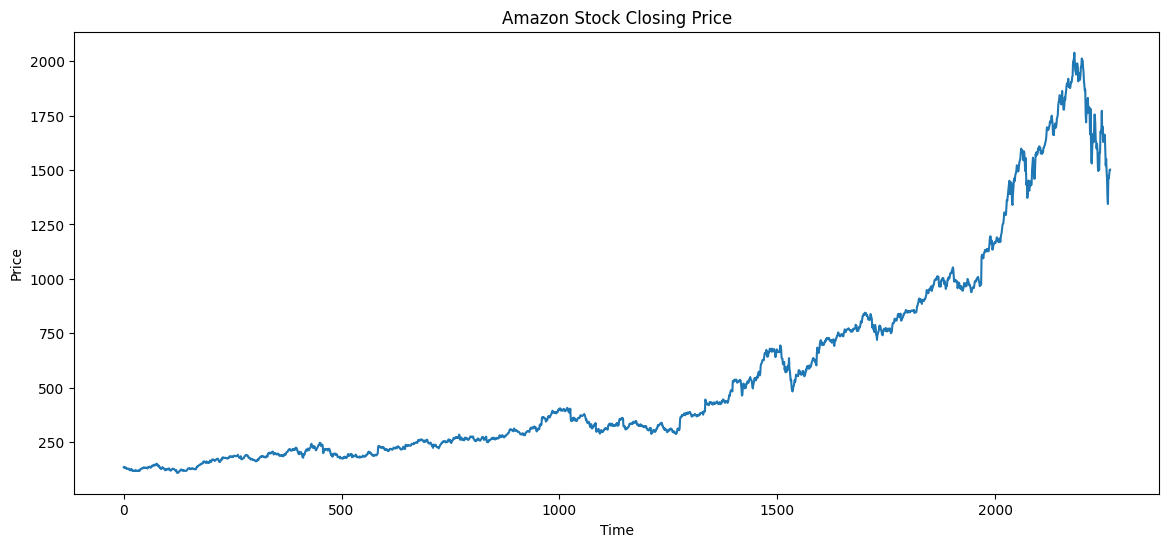

In [6]:
plt.figure(figsize=(14,6))

plt.plot(df['Close'])

plt.title('Amazon Stock Closing Price')
plt.xlabel('Time')
plt.ylabel('Price')

plt.show()

In [7]:
data = df['Close'].values
data = data.reshape(-1,1)

In [8]:
scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data)

In [9]:
training_data_len = int(np.ceil(len(scaled_data) * 0.8))

train_data = scaled_data[0:training_data_len]

In [10]:
X_train = []
y_train = []

for i in range(60, len(train_data)):
    X_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

In [11]:
X_train, y_train = np.array(X_train), np.array(y_train)

In [12]:
X_train = np.reshape(X_train,
                     (X_train.shape[0],
                      X_train.shape[1],
                      1))

In [13]:
model = Sequential()

model.add(LSTM(50,
               return_sequences=True,
               input_shape=(X_train.shape[1],1)))

model.add(Dropout(0.2))

model.add(LSTM(50))

model.add(Dropout(0.2))

model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [15]:
history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=25
)

Epoch 1/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - loss: 0.0029
Epoch 2/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 4.0586e-04
Epoch 3/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 3.1292e-04
Epoch 4/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - loss: 2.8265e-04
Epoch 5/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 2.8338e-04
Epoch 6/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 2.6836e-04
Epoch 7/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 2.3745e-04
Epoch 8/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - loss: 2.3409e-04
Epoch 9/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 2.3962e-04
Epoch 10/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 1.9735e-04
Epoch 11/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 2.3204e-04
Epoch 12/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 2.1248e-04
Epoch 13/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 2.4037e-04
Epoch 14/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 1.9044e-04
Epoch 15/25
55/55 ━

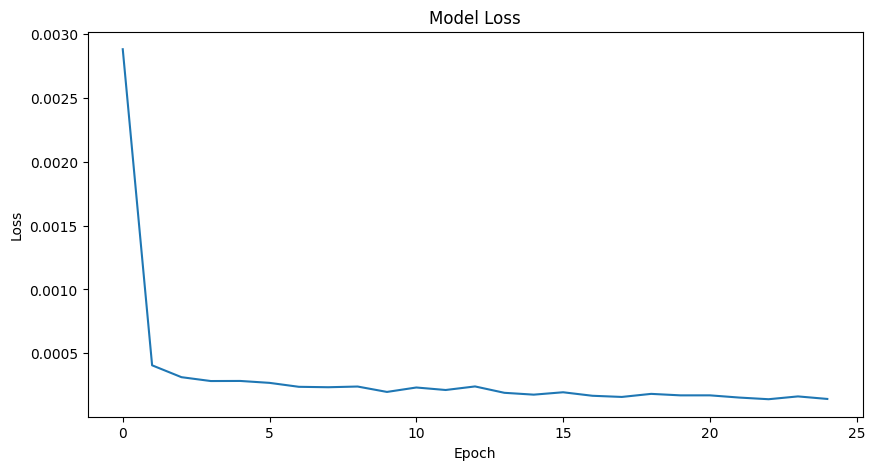

In [16]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

In [17]:
test_data = scaled_data[training_data_len - 60:]

X_test = []
y_test = data[training_data_len:]

In [18]:
for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i, 0])

In [19]:
X_test = np.array(X_test)

X_test = np.reshape(X_test,
                    (X_test.shape[0],
                     X_test.shape[1],
                     1))

In [20]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step


/tmp/ipykernel_3385/2497259625.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


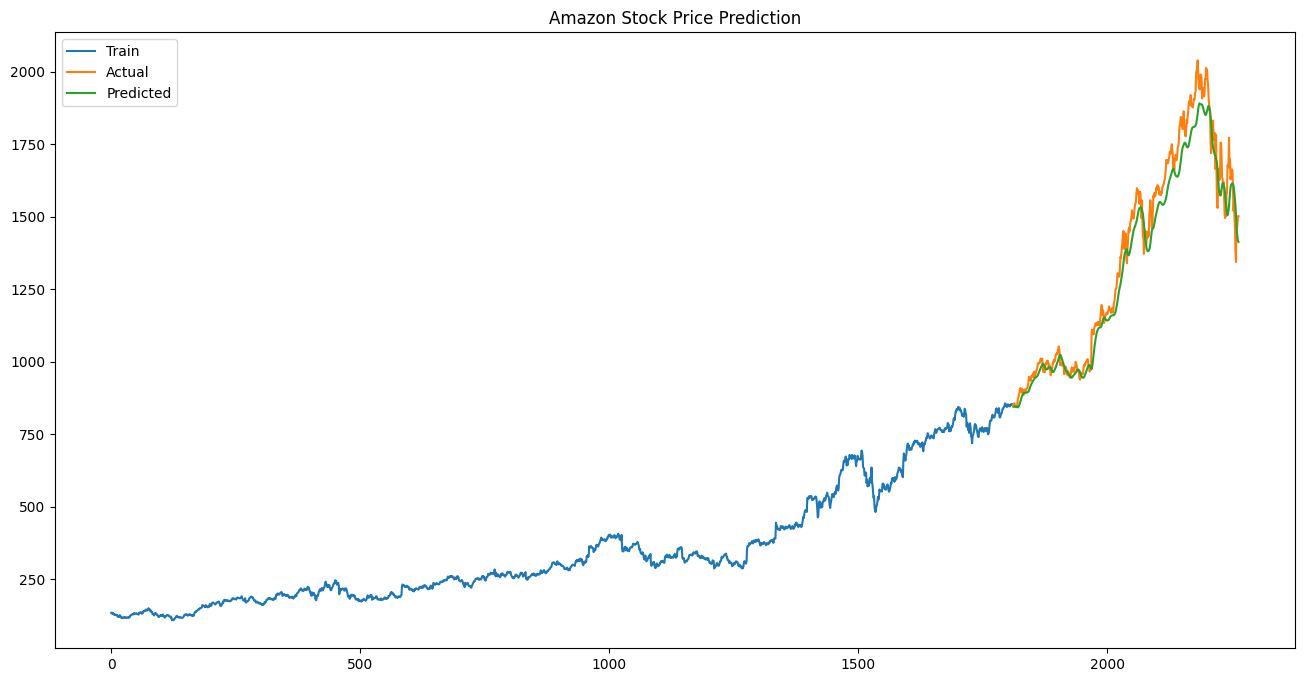

In [21]:
train = df[:training_data_len]
valid = df[training_data_len:]

valid['Predictions'] = predictions

plt.figure(figsize=(16,8))

plt.plot(train['Close'])
plt.plot(valid[['Close','Predictions']])

plt.legend(['Train','Actual','Predicted'])

plt.title('Amazon Stock Price Prediction')

plt.show()

In [22]:
from sklearn.metrics import mean_squared_error
import math

rmse = np.sqrt(mean_squared_error(
    valid['Close'],
    valid['Predictions']
))

print("RMSE:", rmse)

RMSE: 67.93755468331315


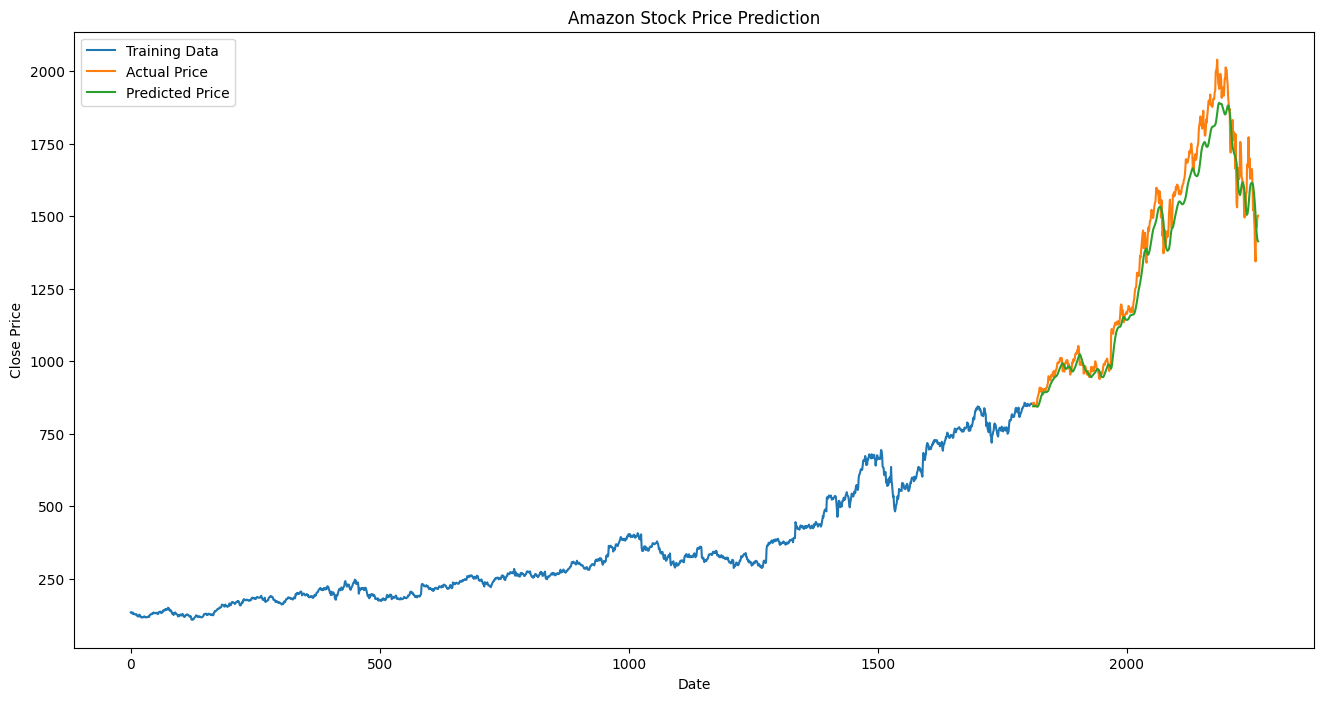

In [23]:
plt.figure(figsize=(16,8))

plt.title('Amazon Stock Price Prediction')

plt.plot(train['Close'], label='Training Data')

plt.plot(valid['Close'], label='Actual Price')

plt.plot(valid['Predictions'], label='Predicted Price')

plt.xlabel('Date')
plt.ylabel('Close Price')

plt.legend()

plt.show()

In [24]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [25]:
mae = mean_absolute_error(
    valid['Close'],
    valid['Predictions']
)

print("MAE:", mae)

MAE: 53.00390409626794


In [26]:
r2 = r2_score(
    valid['Close'],
    valid['Predictions']
)

print("R2 Score:", r2)

R2 Score: 0.963224673154016


In [27]:
last_60_days = scaled_data[-60:]

In [28]:
future_input = last_60_days.reshape(1,60,1)

In [29]:
future_price = model.predict(future_input)

future_price = scaler.inverse_transform(future_price)

print("Next Day Predicted Price:",
      future_price)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Next Day Predicted Price: [[1414.9432]]


In [30]:
model.save('amazon_lstm_model.h5')

In [31]:
from google.colab import files

files.download('amazon_lstm_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
plt.savefig('prediction_graph.png')

<Figure size 640x480 with 0 Axes>